# ALS 5.3.1 Shadow4 Digital twin for blop
khchan@lbl.gov, awojdyla@lbl.gov, August 2026

### Controlling the beamline via EPICS (caproto)

The degrees of freedom (DOFs) of this beamline are exposed as EPICS process variables by a standalone `caproto` IOC (`als531_shadow4_ioc.py`). Before running the cells below, start the IOC in a separate terminal:

```bash
python als531_shadow4_ioc.py
```

The IOC exposes:
- Ten DOF PVs under `ALS531S4:DOF:*` (writable; writing any value automatically triggers a re-trace of the beamline)
- An areaDetector-style camera interface under `ALS531S4:cam1:*` / `ALS531S4:image1:ArrayData`, matching the convention already used elsewhere in this repository for the real ALS 5.3.1 cameras
- A convenience scalar `ALS531S4:SIM:INTENSITY_TOTAL`

This notebook acts purely as an EPICS **client**: it writes DOF values and reads back the simulated camera image, exactly as it would for a real beamline.

In [ ]:
import time
import numpy as np
import ophyd
ophyd.set_cl('caproto')
from ophyd import EpicsSignal

PREFIX = 'ALS531S4:'

# Degree-of-freedom PVs (writable; writing triggers an automatic re-trace)
dof_m1_rel_pitch_deg = EpicsSignal(PREFIX + 'DOF:M1_REL_PITCH_DEG', name='dof_m1_rel_pitch_deg')
dof_m1_bending_m = EpicsSignal(PREFIX + 'DOF:M1_BENDING_M', name='dof_m1_bending_m')
dof_mono_height_m = EpicsSignal(PREFIX + 'DOF:MONO_HEIGHT_M', name='dof_mono_height_m')
dof_mono_angle_rel_angle_deg = EpicsSignal(PREFIX + 'DOF:MONO_ANGLE_REL_ANGLE_DEG', name='dof_mono_angle_rel_angle_deg')
dof_hexapod_rel_x_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_X_M', name='dof_hexapod_rel_x_m')
dof_hexapod_rel_y_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Y_M', name='dof_hexapod_rel_y_m')
dof_hexapod_rel_z_m = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_Z_M', name='dof_hexapod_rel_z_m')
dof_hexapod_rel_Rx_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RX_DEG', name='dof_hexapod_rel_Rx_deg')
dof_hexapod_rel_Ry_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RY_DEG', name='dof_hexapod_rel_Ry_deg')
dof_hexapod_rel_Rz_deg = EpicsSignal(PREFIX + 'DOF:HEXAPOD_REL_RZ_DEG', name='dof_hexapod_rel_Rz_deg')

dof_signals = [
    dof_m1_rel_pitch_deg, dof_m1_bending_m, dof_mono_height_m, dof_mono_angle_rel_angle_deg,
    dof_hexapod_rel_x_m, dof_hexapod_rel_y_m, dof_hexapod_rel_z_m,
    dof_hexapod_rel_Rx_deg, dof_hexapod_rel_Ry_deg, dof_hexapod_rel_Rz_deg,
]

# AreaDetector-style camera PVs (read-only from the client's perspective,
# except `cam1:Acquire`, which can be used to manually force a re-trace)
cam_acquire = EpicsSignal(PREFIX + 'cam1:Acquire', name='cam_acquire')
cam_acquire_rbv = EpicsSignal(PREFIX + 'cam1:Acquire_RBV', name='cam_acquire_rbv')
cam_done = EpicsSignal(PREFIX + 'cam1:Done', name='cam_done')
cam_array_counter_rbv = EpicsSignal(PREFIX + 'cam1:ArrayCounter_RBV', name='cam_array_counter_rbv')
cam_array_size_x_rbv = EpicsSignal(PREFIX + 'cam1:ArraySizeX_RBV', name='cam_array_size_x_rbv')
cam_array_size_y_rbv = EpicsSignal(PREFIX + 'cam1:ArraySizeY_RBV', name='cam_array_size_y_rbv')
image_array_data = EpicsSignal(PREFIX + 'image1:ArrayData', name='image_array_data')
sim_intensity_total = EpicsSignal(PREFIX + 'SIM:INTENSITY_TOTAL', name='sim_intensity_total')

for sig in dof_signals + [cam_acquire, cam_acquire_rbv, cam_done, cam_array_counter_rbv,
                          cam_array_size_x_rbv, cam_array_size_y_rbv,
                          image_array_data, sim_intensity_total]:
    sig.wait_for_connection(timeout=10)

print('Connected to IOC at prefix', PREFIX)


def wait_for_acquisition(poll_interval=0.2, timeout=120):
    """Block until the IOC finishes an in-progress (or about-to-start)
    beamline re-trace, i.e. until cam1:Done reads back 1.

    Note: cam1:Done (unlike cam1:Acquire_RBV, which pulses
    0 -> 1 -> 0 around the trace and can race with a caller that starts
    polling after a very fast trace has already completed) is reset to
    0 the instant a trace starts and set back to 1 only once it has
    fully finished, so it is safe to poll immediately after triggering.
    """
    t0 = time.time()
    while time.time() - t0 < timeout:
        if bool(cam_done.get()):
            return
        time.sleep(poll_interval)
    raise TimeoutError('Timed out waiting for beamline re-trace to complete')


def get_camera_image():
    """Read back the current camera image from the IOC and reshape it
    into a 2D (ny, nx) array."""
    nx = int(cam_array_size_x_rbv.get())
    ny = int(cam_array_size_y_rbv.get())
    flat = np.asarray(image_array_data.get())
    return flat.reshape((ny, nx))

Connected to IOC at prefix ALS531S4:


In [67]:
# Set degree-of-freedom values (matching the defaults previously
# hard-coded in this notebook). Writing any DOF PV automatically
# triggers the IOC to re-run the full Shadow4 beamline trace in the
# background.
dof_m1_rel_pitch_deg.put(-0.0000)
dof_m1_bending_m.put(2400)
dof_mono_height_m.put(0)
dof_mono_angle_rel_angle_deg.put(0.00)
dof_hexapod_rel_x_m.put(0)
dof_hexapod_rel_y_m.put(0)
dof_hexapod_rel_z_m.put(0)
dof_hexapod_rel_Rx_deg.put(0)
dof_hexapod_rel_Ry_deg.put(0)
dof_hexapod_rel_Rz_deg.put(0)

wait_for_acquisition()
print('Trace complete. Frame counter:', cam_array_counter_rbv.get())
print('Total intensity:', sim_intensity_total.get())

Trace complete. Frame counter: 34
Total intensity: 49931.76227226681


In [65]:
from als531_shadow4_sim import CAMERA_X_M, CAMERA_Y_M, CAMERA_NX, CAMERA_NY

camera_image = get_camera_image()
intensity_total = sim_intensity_total.get()

grid_x_m = np.linspace(-CAMERA_X_M / 2, CAMERA_X_M / 2, CAMERA_NX)
grid_y_m = np.linspace(-CAMERA_Y_M / 2, CAMERA_Y_M / 2, CAMERA_NY)

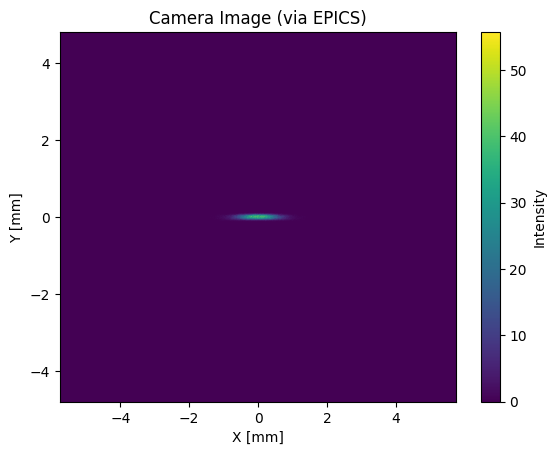

In [66]:
import matplotlib.pyplot as plt
# plot in mm
plt.imshow(camera_image, extent=[grid_x_m[0]*1e3, grid_x_m[-1]*1e3, grid_y_m[0]*1e3, grid_y_m[-1]*1e3], origin='lower', aspect='auto')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')
plt.title('Camera Image (via EPICS)')
plt.colorbar(label='Intensity')
plt.show()